# Executive Summary

This project analyzes supply chain and business performance data to evaluate product demand, customer purchasing behavior, inventory management efficiency, logistics operations, and supplier performance across multiple product categories.

The analysis focuses on identifying revenue-driving products, customer demand patterns, inventory availability risks, replenishment responsiveness, transportation cost efficiency, and supplier operational performance. Key business metrics such as revenue generation, sales volume, stock levels, lead times, logistics costs, manufacturing efficiency, and defect rates are examined to uncover operational trends and potential supply chain challenges.

The project aims to provide data-driven insights that support better inventory planning, demand forecasting, supplier evaluation, logistics optimization, and overall supply chain decision-making. Through exploratory data analysis and business-focused performance evaluation, the findings help highlight operational strengths, inefficiencies, and areas requiring process improvement across the supply chain network.

## 1.Dataset Preview

Displaying the initial records of the dataset to understand the overall structure, feature composition, and available supply chain and business-related variables prior to exploratory data analysis.

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/supply_chain_data.csv")

df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


# 2.Data Understanding and Quality Assessment

Performing preliminary exploratory data analysis to understand the dataset structure, evaluate data quality, identify missing or duplicate records, and review statistical distributions before conducting business and supply chain analysis.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    str    
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    str    
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    str    
 14  Location                 100 non-null 

In [11]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [12]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='str')

# 3.Revenue Performance Analysis

Analyzing total revenue, average product pricing, and sales volume across product categories to evaluate revenue contribution, pricing strategy, customer demand intensity, and overall market performance.

In [57]:
# Revenue Performance Analysis

revenue_by_product = df.groupby('Product type')['Revenue generated'].sum()

revenue_performance = df.groupby('Product type').agg(
    Total_Revenue=('Revenue generated', 'sum'),
    Average_Price=('Price', 'mean'),
    Products_Sold=('Number of products sold', 'sum')
)

# Calculate revenue contribution percentage
total_revenue = revenue_performance['Total_Revenue'].sum()

revenue_performance['Revenue_Contribution_%'] = (
    revenue_performance['Total_Revenue'] / total_revenue * 100
)

# Store numeric contribution values for visualization
revenue_contribution = revenue_performance['Revenue_Contribution_%']

# Formatting
revenue_performance['Total_Revenue'] = revenue_performance[
    'Total_Revenue'
].apply(lambda x: f"${x/1000:.1f}K")

revenue_performance['Average_Price'] = revenue_performance[
    'Average_Price'
].apply(lambda x: f"${x:.2f}")

revenue_performance['Products_Sold'] = revenue_performance[
    'Products_Sold'
].apply(lambda x: f"{x:,.0f}")

revenue_performance['Revenue_Contribution_%'] = revenue_performance[
    'Revenue_Contribution_%'
].apply(lambda x: f"{x:.1f}%")

revenue_performance

,Total_Revenue,Average_Price,Products_Sold,Revenue_Contribution_%
Product type,,,,
cosmetics,$161.5K,$57.36,"11,757",28.0%
haircare,$174.5K,$46.01,"13,611",30.2%
skincare,$241.6K,$47.26,"20,731",41.8%


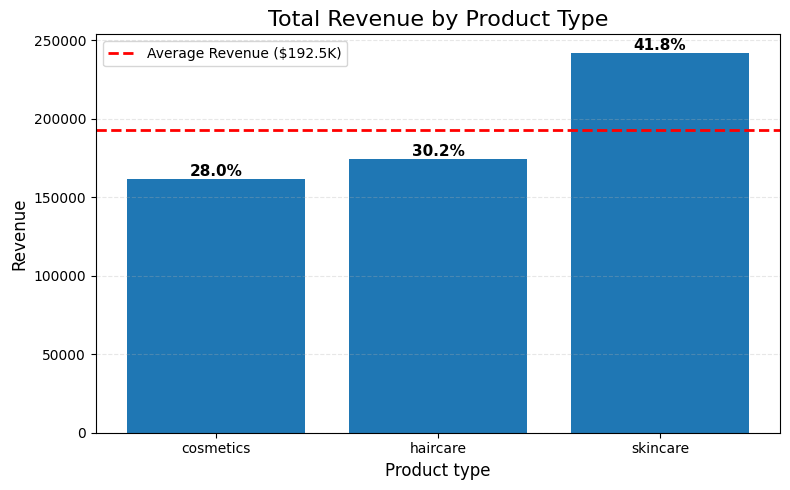

In [58]:
avg_revenue = revenue_by_product.mean()

plt.figure(figsize=(8,5))

bars = plt.bar(
    revenue_by_product.index,
    revenue_by_product.values
)

# Average revenue reference line
plt.axhline(
    avg_revenue,
    linestyle='--',
    linewidth=2,
    color='red',
    label=f'Average Revenue (${avg_revenue/1000:.1f}K)'
)

# Percentage contribution labels
for bar, pct in zip(bars, revenue_contribution.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2000,
        f'{pct:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Total Revenue by Product Type', fontsize=16)
plt.xlabel('Product type', fontsize=12)
plt.ylabel('Revenue', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()



### Insight

Skincare products generated the highest total revenue at approximately $241.6K, contributing 41.8% of total revenue and remaining the only product category above the overall average revenue benchmark of $192.5K. The category also maintained the highest sales volume with over 20.7K units sold, indicating strong customer demand and frequent purchasing activity.

Haircare products contributed approximately 30.2% of total revenue with around 13.6K units sold, maintaining relatively balanced performance across revenue, pricing, and sales volume metrics while remaining slightly below the overall category average revenue level.

Cosmetics products contributed approximately 28.0% of total revenue while maintaining the highest average product price at $57.36, suggesting revenue generation is supported more by premium pricing strategy than by sales volume alone.

Overall, the analysis highlights differing revenue and demand patterns across product categories, with skincare operating as a high-demand, volume-driven segment, cosmetics reflecting a higher-value pricing strategy, and haircare maintaining comparatively stable market performance across operational metrics.


# 4.Sales & Customer Analysis

Analyzing revenue contribution, product sales volume, order quantities, and customer demographic purchasing patterns across product categories to identify high-demand segments, customer behavior trends, demand preferences, and key revenue-driving customer groups.

In [21]:
filtered_df = df[df['Customer demographics'] != 'Unknown']

sales_customer_analysis = filtered_df.groupby(
    'Customer demographics'
).agg(
    Total_Revenue=('Revenue generated', 'sum'),
    Products_Sold=('Number of products sold', 'sum'),
    Total_Orders=('Order quantities', 'sum')
)

# Contribution percentages
total_revenue = sales_customer_analysis['Total_Revenue'].sum()
total_products = sales_customer_analysis['Products_Sold'].sum()
total_orders = sales_customer_analysis['Total_Orders'].sum()

sales_customer_analysis['Revenue_Contribution_%'] = (
    sales_customer_analysis['Total_Revenue'] / total_revenue * 100
)

sales_customer_analysis['Product_Sales_Contribution_%'] = (
    sales_customer_analysis['Products_Sold'] / total_products * 100
)

sales_customer_analysis['Order_Contribution_%'] = (
    sales_customer_analysis['Total_Orders'] / total_orders * 100
)

# Formatting
sales_customer_analysis['Total_Revenue'] = sales_customer_analysis[
    'Total_Revenue'
].apply(lambda x: f"${x/1000:.1f}K")

sales_customer_analysis['Revenue_Contribution_%'] = sales_customer_analysis[
    'Revenue_Contribution_%'
].apply(lambda x: f"{x:.1f}%")

sales_customer_analysis['Product_Sales_Contribution_%'] = sales_customer_analysis[
    'Product_Sales_Contribution_%'
].apply(lambda x: f"{x:.1f}%")

sales_customer_analysis['Order_Contribution_%'] = sales_customer_analysis[
    'Order_Contribution_%'
].apply(lambda x: f"{x:.1f}%")

sales_customer_analysis

,Total_Revenue,Products_Sold,Total_Orders,Revenue_Contribution_%,Product_Sales_Contribution_%,Order_Contribution_%
Customer demographics,,,,,,
Female,$161.5K,12801,1141,39.9%,41.4%,34.2%
Male,$126.6K,7507,899,31.3%,24.3%,27.0%
Non-binary,$116.4K,10580,1292,28.8%,34.3%,38.8%


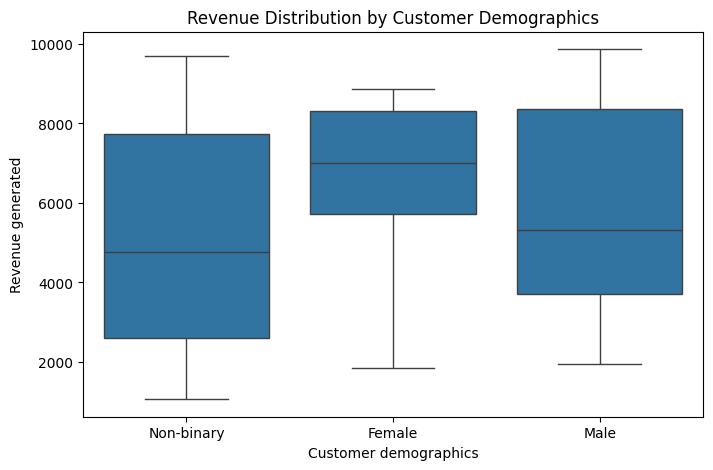

In [10]:
filtered_df = df[df['Customer demographics'] != 'Unknown']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Customer demographics',
    y='Revenue generated',
    data=filtered_df
)

plt.title('Revenue Distribution by Customer Demographics')

plt.show()

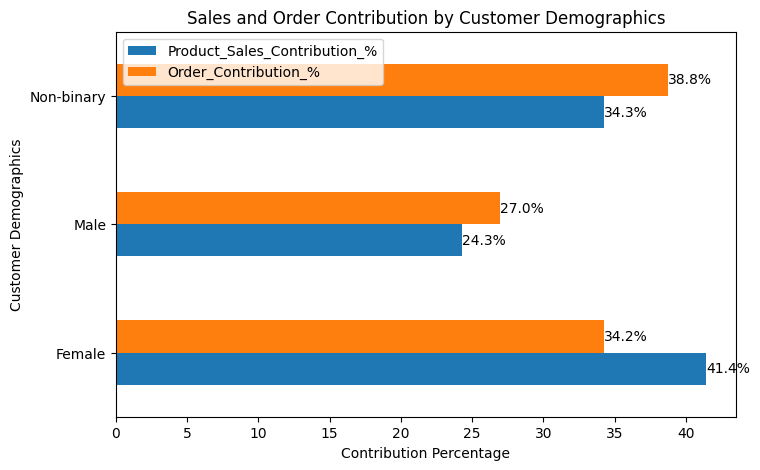

In [36]:
filtered_df = df[df['Customer demographics'] != 'Unknown']

customer_summary = filtered_df.groupby(
    'Customer demographics'
).agg(
    Products_Sold=('Number of products sold', 'sum'),
    Total_Orders=('Order quantities', 'sum')
)

customer_summary['Product_Sales_Contribution_%'] = (
    customer_summary['Products_Sold']
    / customer_summary['Products_Sold'].sum()
    * 100
)

customer_summary['Order_Contribution_%'] = (
    customer_summary['Total_Orders']
    / customer_summary['Total_Orders'].sum()
    * 100
)

customer_summary = customer_summary[
    ['Product_Sales_Contribution_%', 'Order_Contribution_%']
]

ax = customer_summary.plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Sales and Order Contribution by Customer Demographics')
plt.xlabel('Contribution Percentage')
plt.ylabel('Customer Demographics')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

### Insight

Female customers demonstrate the strongest overall business contribution, generating 39.9% of total revenue and 41.4% of total product sales. The revenue distribution analysis also shows consistently higher median revenue values, indicating strong and stable purchasing behavior across transactions.

Non-binary customers contribute 34.3% of total product sales and the highest order contribution at 38.8%, highlighting strong customer engagement and high purchasing frequency despite comparatively lower overall revenue contribution.

Male customers contribute 31.3% of total revenue, 24.3% of product sales, and 27.0% of total orders, reflecting relatively moderate but balanced purchasing activity across the business.

Overall, the analysis reveals clear demographic-based purchasing patterns, where female customers drive higher revenue value while non-binary customers contribute stronger order activity and engagement levels.


# 5.Inventory & Availability Analysis

Analyzing inventory levels, product availability, and sales demand across product categories to evaluate inventory efficiency, supply-demand balance, and potential stock management risks.

In [13]:
inventory_performance = df.groupby('Product type').agg(
    Average_Stock_Level=('Stock levels', 'mean'),
    Average_Availability=('Availability', 'mean'),
    Products_Sold=('Number of products sold', 'sum')
)

inventory_performance['Average_Stock_Level'] = inventory_performance[
    'Average_Stock_Level'
].apply(lambda x: f"{x:.1f}")

inventory_performance['Average_Availability'] = inventory_performance[
    'Average_Availability'
].apply(lambda x: f"{x:.1f}")

inventory_performance['Products_Sold'] = inventory_performance[
    'Products_Sold'
].apply(lambda x: f"{x:,.0f}")

inventory_performance

,Average_Stock_Level,Average_Availability,Products_Sold
Product type,,,
cosmetics,58.7,51.2,"11,757"
haircare,48.4,43.3,"13,611"
skincare,40.2,50.9,"20,731"


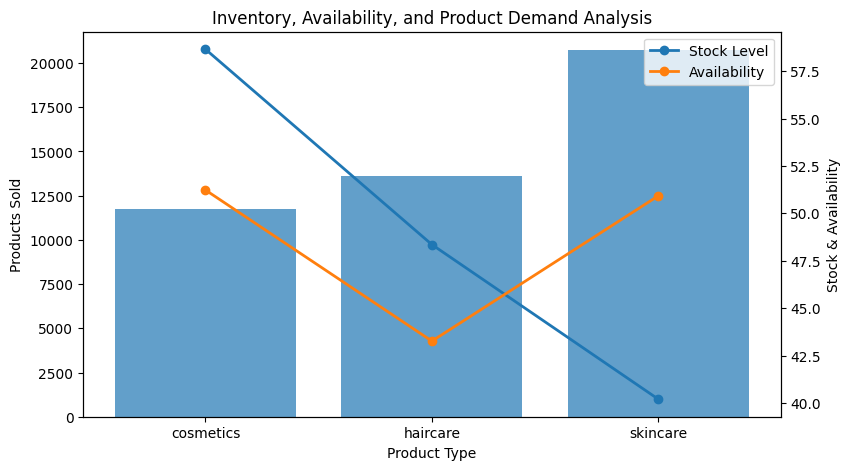

In [40]:
inventory_chart = df.groupby('Product type').agg(
    Average_Stock_Level=('Stock levels', 'mean'),
    Average_Availability=('Availability', 'mean'),
    Products_Sold=('Number of products sold', 'sum')
)

fig, ax1 = plt.subplots(figsize=(9,5))

# Bar chart for products sold
ax1.bar(
    inventory_chart.index,
    inventory_chart['Products_Sold'],
    alpha=0.7
)

ax1.set_ylabel('Products Sold')
ax1.set_xlabel('Product Type')

# Second axis for stock & availability
ax2 = ax1.twinx()

ax2.plot(
    inventory_chart.index,
    inventory_chart['Average_Stock_Level'],
    marker='o',
    linewidth=2,
    label='Stock Level'
)

ax2.plot(
    inventory_chart.index,
    inventory_chart['Average_Availability'],
    marker='o',
    linewidth=2,
    label='Availability'
)

ax2.set_ylabel('Stock & Availability')

plt.title('Inventory, Availability, and Product Demand Analysis')

ax2.legend()

plt.show()

### Insight

Skincare products account for the highest sales volume with 20,731 units sold, despite maintaining the lowest average stock level (40.2), indicating strong customer demand and increased inventory pressure.

Cosmetics products maintain the highest average stock level (58.7) and highest product availability (51.2) while generating the lowest sales volume at 11,757 units, suggesting slower inventory turnover and higher inventory buffering.

Haircare products maintain moderate stock levels (48.4), lower availability (43.3), and balanced sales performance with 13,611 units sold, reflecting more stable inventory management and supply-demand alignment.

Overall, skincare contributes approximately 45% of total product sales volume while operating with lower inventory reserves, highlighting a higher potential risk of stock shortages during periods of strong demand.

# 6.Product Replenishment Analysis

Analyzing product replenishment lead times across product categories to identify inventory responsiveness, operational delays, and potential stockout risks.

In [59]:
lead_time_by_product = df.groupby('Product type')['Lead times'].mean()

lead_time_by_product.apply(lambda x: f"{x:.1f} days")

Product type
cosmetics    15.4 days
haircare     15.5 days
skincare     16.7 days
Name: Lead times, dtype: str

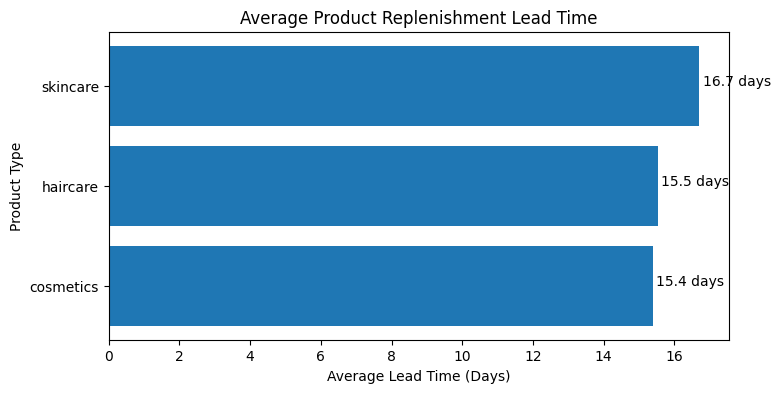

In [41]:
lead_time_by_product = df.groupby(
    'Product type'
)['Lead times'].mean().sort_values()

plt.figure(figsize=(8,4))

plt.barh(
    lead_time_by_product.index,
    lead_time_by_product.values
)

plt.xlabel('Average Lead Time (Days)')
plt.ylabel('Product Type')

plt.title('Average Product Replenishment Lead Time')

for index, value in enumerate(lead_time_by_product.values):
    plt.text(value + 0.1, index, f"{value:.1f} days")

plt.show()

### Insight

Skincare products maintain the highest average replenishment lead time at 16.7 days, indicating slower inventory responsiveness and a higher potential risk of stock shortages during periods of strong demand.

Haircare products follow closely with an average lead time of 15.5 days, suggesting moderate replenishment delays that may impact inventory flexibility and supply responsiveness.

Cosmetics products maintain the shortest average lead time at 15.4 days, supporting faster inventory replenishment and improved operational responsiveness compared to other product categories.

Overall, the analysis shows that skincare products experience approximately 8.4% longer replenishment lead times than cosmetics products, highlighting greater inventory pressure within the skincare category.


# 7.Logistics & Carrier Analysis

Analyzing shipping carrier performance, transportation efficiency, delivery responsiveness, and logistics cost patterns across the supply chain network.

## 7.1 Carrier Performance Analysis

Evaluating shipping carrier efficiency based on shipping costs and delivery times to identify operationally efficient logistics providers.

In [61]:
carrier_performance = df.groupby('Shipping carriers').agg(
    Average_Shipping_Cost=('Shipping costs', 'mean'),
    Average_Shipping_Time=('Shipping times', 'mean')
)

carrier_performance['Average_Shipping_Cost'] = carrier_performance[
    'Average_Shipping_Cost'
].apply(lambda x: f"${x:.2f}")

carrier_performance['Average_Shipping_Time'] = carrier_performance[
    'Average_Shipping_Time'
].apply(lambda x: f"{x:.1f} days")

carrier_performance

,Average_Shipping_Cost,Average_Shipping_Time
Shipping carriers,,
Carrier A,$5.55,6.1 days
Carrier B,$5.51,5.3 days
Carrier C,$5.60,6.0 days


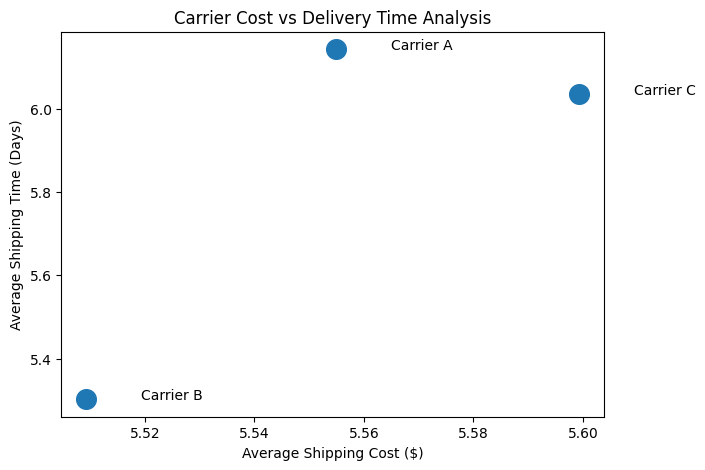

In [42]:
carrier_chart = df.groupby('Shipping carriers').agg(
    Average_Shipping_Cost=('Shipping costs', 'mean'),
    Average_Shipping_Time=('Shipping times', 'mean')
)

plt.figure(figsize=(7,5))

plt.scatter(
    carrier_chart['Average_Shipping_Cost'],
    carrier_chart['Average_Shipping_Time'],
    s=200
)

for carrier in carrier_chart.index:
    plt.text(
        carrier_chart.loc[carrier, 'Average_Shipping_Cost'] + 0.01,
        carrier_chart.loc[carrier, 'Average_Shipping_Time'],
        carrier
    )

plt.xlabel('Average Shipping Cost ($)')
plt.ylabel('Average Shipping Time (Days)')

plt.title('Carrier Cost vs Delivery Time Analysis')

plt.show()

### Insight

Carrier B demonstrates the strongest operational efficiency, maintaining the lowest average shipping cost at approximately $5.51 while also achieving the fastest average delivery time of 5.3 days.

Carrier A maintains a slightly higher average shipping cost of approximately $5.56 with an average delivery time of 6.1 days, indicating moderate logistics efficiency compared to Carrier B.

Carrier C records the highest average shipping cost at approximately $5.60 and an average delivery time of 6.0 days, making it the least cost-efficient carrier among the three providers.

Overall, shipping costs remain relatively standardized across carriers, with less than a 2% cost difference between the lowest and highest-cost providers. However, Carrier B achieves approximately 13% faster delivery performance compared to Carrier A while maintaining the lowest operational cost.

## 7.2 Transportation Mode Analysis

Analyzing transportation modes based on logistics costs and shipping times to evaluate transportation efficiency and operational tradeoffs across the supply chain.

In [18]:
transportation_performance = df.groupby(
    'Transportation modes'
).agg(
    Average_Logistics_Cost=('Costs', 'mean'),
    Total_Logistics_Cost=('Costs', 'sum')
)

# Cost contribution percentage
total_cost = transportation_performance['Total_Logistics_Cost'].sum()

transportation_performance['Cost_Contribution_%'] = (
    transportation_performance['Total_Logistics_Cost'] / total_cost * 100
)

# Formatting
transportation_performance['Average_Logistics_Cost'] = transportation_performance[
    'Average_Logistics_Cost'
].apply(lambda x: f"${x:.2f}")

transportation_performance['Total_Logistics_Cost'] = transportation_performance[
    'Total_Logistics_Cost'
].apply(lambda x: f"${x/1000:.1f}K")

transportation_performance['Cost_Contribution_%'] = transportation_performance[
    'Cost_Contribution_%'
].apply(lambda x: f"{x:.1f}%")

transportation_performance

,Average_Logistics_Cost,Total_Logistics_Cost,Cost_Contribution_%
Transportation modes,,,
Air,$561.71,$14.6K,27.6%
Rail,$541.75,$15.2K,28.7%
Road,$553.39,$16.0K,30.3%
Sea,$417.82,$7.1K,13.4%


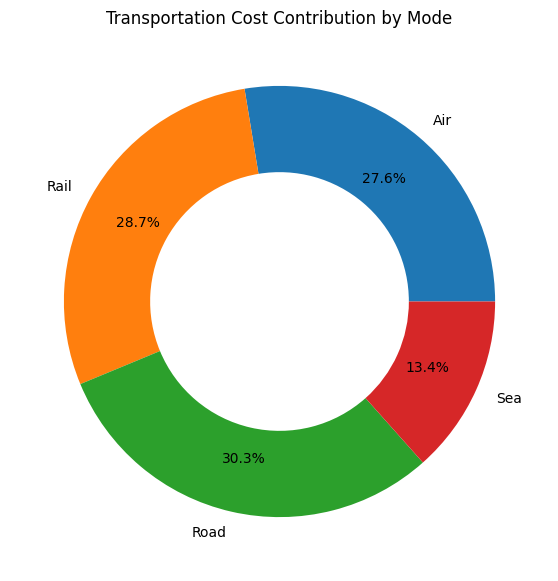

In [45]:
transport_chart = df.groupby('Transportation modes').agg(
    Total_Logistics_Cost=('Costs', 'sum')
)

# Cost contribution %
total_cost = transport_chart['Total_Logistics_Cost'].sum()

transport_chart['Cost_Contribution_%'] = (
    transport_chart['Total_Logistics_Cost'] / total_cost * 100
)

plt.figure(figsize=(7,7))

plt.pie(
    transport_chart['Cost_Contribution_%'],
    labels=transport_chart.index,
    autopct='%1.1f%%',
    pctdistance=0.75,   # moves percentages inside
    wedgeprops={'width':0.4}
)

plt.title('Transportation Cost Contribution by Mode')

plt.show()

### Insight

Road transportation contributes the highest share of total logistics costs at 30.3%, indicating its dominant role in overall supply chain transportation activity and operational distribution.

Air transportation maintains the highest average logistics cost at $561.71 while accounting for 27.6% of total logistics costs, reflecting the premium expense associated with faster and more responsive delivery methods.

Rail transportation contributes 28.7% of total logistics costs with relatively balanced average transportation expenses, supporting its position as a cost-stable transportation mode across the logistics network.

Sea transportation demonstrates the strongest cost efficiency, maintaining the lowest average logistics cost ($417.82) and the smallest overall cost contribution (13.4%), making it suitable for large-scale and lower-priority shipments.

Overall, the analysis highlights clear transportation cost trade-offs across logistics modes, emphasizing the balance between operational speed, transportation efficiency, and supply chain cost optimization.



# 8.Supplier Performance Analysis

Analyzing supplier manufacturing efficiency, production capacity, operational responsiveness, production cost structures, and product quality performance across the supplier network.

In [71]:
supplier_performance = df.groupby('Supplier name').agg(
    Average_Production_Volume=('Production volumes', 'mean'),
    Average_Manufacturing_Lead_Time=('Manufacturing lead time', 'mean'),
    Average_Manufacturing_Cost=('Manufacturing costs', 'mean'),
    Average_Defect_Rate=('Defect rates', 'mean')
)

supplier_performance['Average_Production_Volume'] = supplier_performance[
    'Average_Production_Volume'
].apply(lambda x: f"{x:.0f}")

supplier_performance['Average_Manufacturing_Lead_Time'] = supplier_performance[
    'Average_Manufacturing_Lead_Time'
].apply(lambda x: f"{x:.1f} days")

supplier_performance['Average_Manufacturing_Cost'] = supplier_performance[
    'Average_Manufacturing_Cost'
].apply(lambda x: f"${x:.2f}")

supplier_performance['Average_Defect_Rate'] = supplier_performance[
    'Average_Defect_Rate'
].apply(lambda x: f"{x:.2f}%")

supplier_performance

,Average_Production_Volume,Average_Manufacturing_Lead_Time,Average_Manufacturing_Cost,Average_Defect_Rate
Supplier name,,,,
Supplier 1,502,12.6 days,$45.25,1.80%
Supplier 2,641,15.6 days,$41.62,2.36%
Supplier 3,533,14.9 days,$43.63,2.47%
Supplier 4,653,15.3 days,$62.71,2.34%
Supplier 5,521,16.3 days,$44.77,2.67%


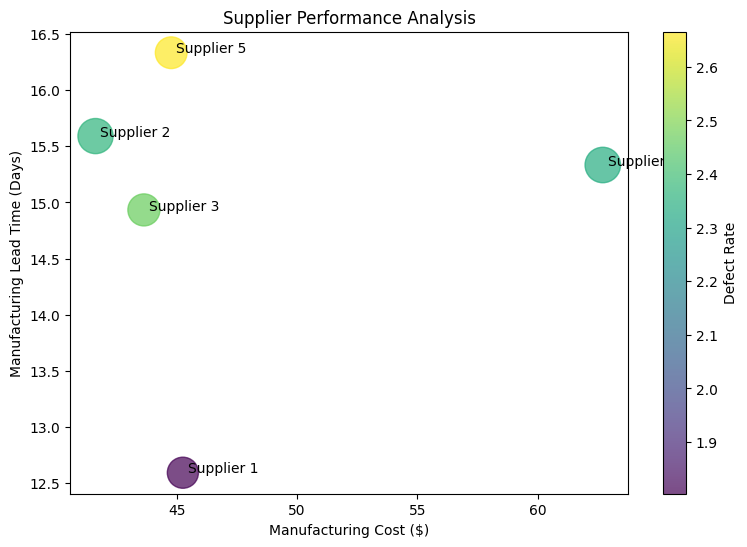

In [46]:
supplier_chart = df.groupby('Supplier name').agg(
    Average_Production_Volume=('Production volumes', 'mean'),
    Average_Manufacturing_Lead_Time=('Manufacturing lead time', 'mean'),
    Average_Manufacturing_Cost=('Manufacturing costs', 'mean'),
    Average_Defect_Rate=('Defect rates', 'mean')
).reset_index()

plt.figure(figsize=(9,6))

scatter = plt.scatter(
    supplier_chart['Average_Manufacturing_Cost'],
    supplier_chart['Average_Manufacturing_Lead_Time'],
    s=supplier_chart['Average_Production_Volume'],
    c=supplier_chart['Average_Defect_Rate'],
    alpha=0.7
)

for i, supplier in enumerate(supplier_chart['Supplier name']):
    plt.text(
        supplier_chart['Average_Manufacturing_Cost'][i] + 0.2,
        supplier_chart['Average_Manufacturing_Lead_Time'][i],
        supplier
    )

plt.xlabel('Manufacturing Cost ($)')
plt.ylabel('Manufacturing Lead Time (Days)')

plt.title('Supplier Performance Analysis')

plt.colorbar(scatter, label='Defect Rate')

plt.show()

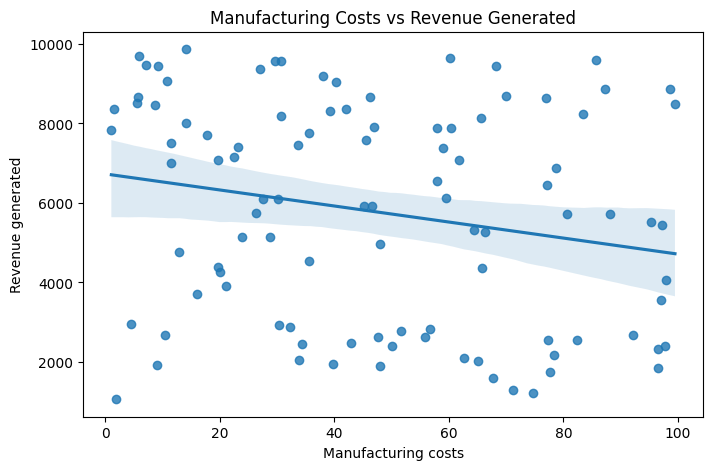

In [19]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='Manufacturing costs',
    y='Revenue generated',
    data=df
)

plt.title('Manufacturing Costs vs Revenue Generated')

plt.show()

### Insight

Supplier 4 maintains the highest production volume at 653 units but also records the highest manufacturing cost at approximately $62.71, indicating higher operational spending to sustain production capacity.

Supplier 1 demonstrates the strongest manufacturing efficiency, maintaining the shortest manufacturing lead time at 12.6 days alongside the lowest defect rate of 1.8%, suggesting stronger production consistency and operational reliability.

Supplier 5 records the longest manufacturing lead time at 16.3 days and the highest defect rate at 2.7%, indicating comparatively weaker operational efficiency and greater quality-control risk within the supplier network.

Supplier 2 and Supplier 3 maintain relatively balanced performance, with production volumes of 641 and 533 units respectively, while keeping manufacturing costs between approximately $41–$44 and defect rates below 2.5%.

Additionally, the regression analysis between manufacturing costs and revenue generated shows a weak negative relationship, indicating that higher manufacturing costs do not consistently translate into higher revenue performance. Several products with elevated manufacturing costs generate only moderate revenue levels, highlighting potential inefficiencies in pricing strategy, production optimization, or profitability management.

Overall, the analysis highlights significant operational differences across suppliers, emphasizing the importance of balancing production capacity, manufacturing efficiency, defect control, and cost optimization within the supply chain network.

# 9.Correlation Analysis

Purpose:

Analyzing relationships between demand, inventory levels, lead times, pricing, logistics costs, manufacturing costs, and operational performance metrics to identify business trends, operational dependencies, and supply chain efficiency patterns.


In [72]:
numeric_columns = [
    'Price',
    'Availability',
    'Number of products sold',
    'Revenue generated',
    'Stock levels',
    'Lead times',
    'Order quantities',
    'Shipping times',
    'Shipping costs',
    'Production volumes',
    'Manufacturing lead time',
    'Manufacturing costs',
    'Defect rates',
    'Costs'
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
Price,1.000000,0.019083,0.005739,0.038424,0.078261,0.044855,0.095819,0.071942,0.058543,-0.124575,-0.301313,-0.184123,-0.147247,0.088501
Availability,0.019083,1.000000,0.087496,-0.075170,-0.025900,0.170439,0.143769,-0.051377,-0.044179,0.050134,0.065333,0.134652,0.040626,-0.027315
Number of products sold,0.005739,0.087496,1.000000,-0.001641,0.022189,-0.046419,0.015992,0.087315,0.044285,0.187945,-0.048939,0.034284,-0.082726,-0.036951
Revenue generated,0.038424,-0.075170,-0.001641,1.000000,-0.158480,-0.057296,0.029422,-0.109211,-0.072892,-0.037441,0.014073,-0.214025,-0.125335,0.027252
Stock levels,0.078261,-0.025900,0.022189,-0.158480,1.000000,0.072571,-0.111455,-0.094883,0.072907,0.043763,-0.050592,0.033243,-0.149478,-0.012088
Lead times,0.044855,0.170439,-0.046419,-0.057296,0.072571,1.000000,0.105459,-0.045156,-0.120746,-0.145324,0.003364,-0.024441,0.015681,0.243686
Order quantities,0.095819,0.143769,0.015992,0.029422,-0.111455,0.105459,1.000000,-0.002561,0.004261,-0.086567,0.112347,-0.026784,0.018986,0.167306
Shipping times,0.071942,-0.051377,0.087315,-0.109211,-0.094883,-0.045156,-0.002561,1.000000,0.045108,-0.060470,-0.016953,0.029132,-0.036673,-0.045541
Shipping costs,0.058543,-0.044179,0.044285,-0.072892,0.072907,-0.120746,0.004261,0.045108,1.000000,-0.097979,-0.005653,0.005984,0.083139,0.051671
Production volumes,-0.124575,0.050134,0.187945,-0.037441,0.043763,-0.145324,-0.086567,-0.060470,-0.097979,1.000000,0.184457,0.051504,0.118853,-0.074927


Matplotlib is building the font cache; this may take a moment.


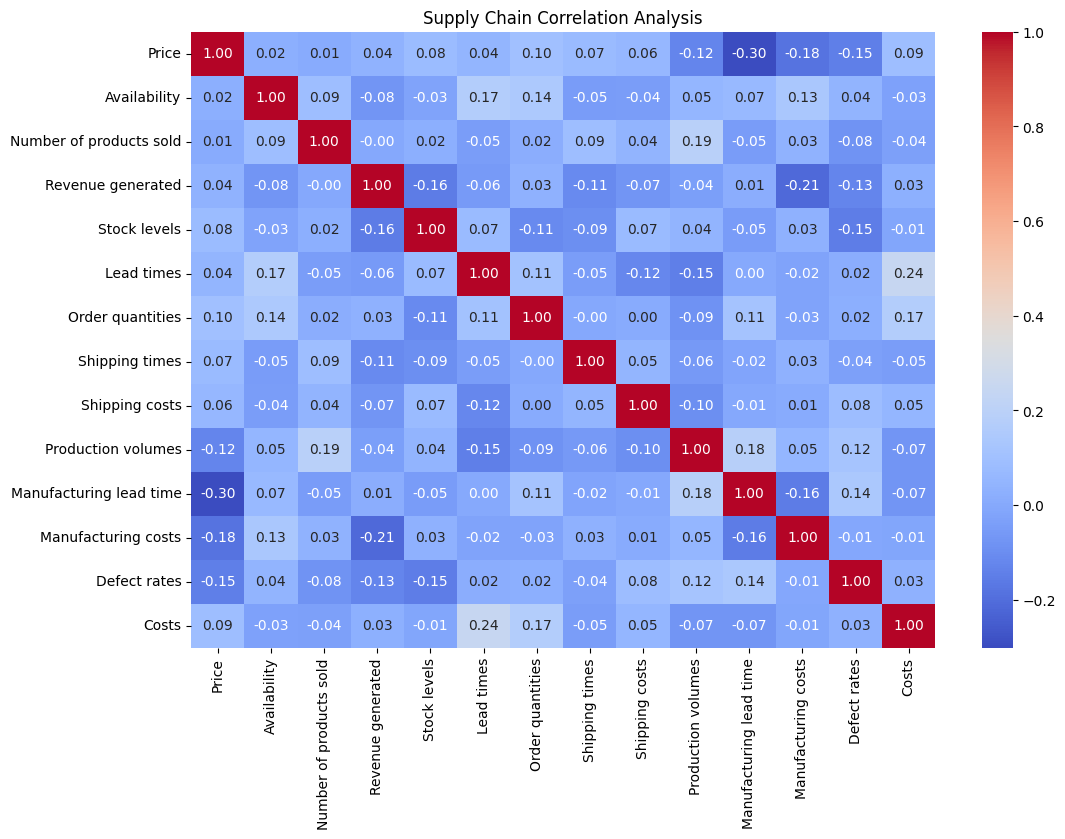

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Supply Chain Correlation Analysis')

plt.show()

### Insight

* The correlation analysis indicates generally weak relationships across most supply chain variables, suggesting that operational performance is influenced by multiple independent business factors.
* A moderate negative correlation between price and manufacturing lead time (-0.30) suggests that higher-priced products tend to maintain faster production turnaround and replenishment efficiency.
* Production volumes show a positive relationship with products sold (0.19), indicating that increased manufacturing output supports stronger customer demand and sales activity.
* Lead times and operational costs maintain a positive correlation (0.24), highlighting that longer replenishment cycles may contribute to higher supply chain operating expenses.
* Revenue generated shows a slight negative relationship with manufacturing costs (-0.21), suggesting that higher manufacturing expenses do not necessarily translate into stronger revenue performance.
* Overall, the analysis provides operational visibility into how inventory, production, logistics, and sales variables interact across the supply chain network, supporting more data-driven planning and performance optimization decisions.

# 10.Recommendations

Based on the analysis findings, several operational and business improvement opportunities can be identified across product management, inventory planning, logistics operations, and supplier performance.

- Strengthen inventory monitoring and replenishment planning for skincare products due to consistently high sales demand, lower average stock levels, and comparatively longer replenishment lead times.

- Evaluate inventory allocation strategies for cosmetics products to reduce potential overstocking and improve inventory turnover efficiency while maintaining product availability.

- Improve demand forecasting and replenishment responsiveness for haircare and skincare categories to minimize operational delays and reduce potential stockout risks during periods of increased customer demand.

- Optimize transportation and logistics cost management by reviewing transportation modes and shipping carrier performance to identify more cost-efficient logistics strategies.

- Continuously monitor supplier manufacturing lead times, production quality, and defect rates to identify operational risks and improve supplier reliability within the supply chain network.

- Utilize customer purchasing behavior insights to support more targeted product positioning, inventory distribution, and customer engagement strategies across different demographic segments.

Overall, the findings highlight the importance of balancing customer demand, inventory responsiveness, supplier efficiency, and logistics performance to improve operational stability and overall supply chain effectiveness.

# Conclusion

The supply chain analysis identified important operational patterns across product categories, customer segments, inventory management, supplier performance, and logistics operations.

The findings reveal that skincare products represent the company’s strongest demand-driven category, generating the highest sales volume and total revenue despite maintaining comparatively lower inventory levels and longer replenishment lead times. In contrast, cosmetics products demonstrate stronger pricing performance and higher inventory availability, while haircare products maintain relatively balanced operational performance across most business metrics.

The analysis also highlighted opportunities for improving inventory optimization, replenishment responsiveness, supplier efficiency, and logistics cost management. Correlation analysis further provided insights into relationships between sales, inventory, lead times, production activity, and operational costs across the supply chain network.

Overall, this project demonstrates how exploratory data analysis and business-focused analytics can support better supply chain decision-making, operational efficiency, demand forecasting, inventory planning, and supplier performance evaluation.